# Classification - Advanced

**Database source:** https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

**Database description:** The SMS Spam Collection is a set of SMS tagged messages that have been collected for SMS Spam research. 
It contains 5,574 SMS messages, each labeled either as:
* `ham` — legitimate message
* `spam` — unsolicited or potentially harmful message

**Database columns:** 
* `v1` - message's label (`spam`/`ham`)
* `v2` - message


## Data Loading 

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer

def remove_punctuation(text):
    import string
    translator = str.maketrans('', '', string.punctuation)
    return text.translate(translator)

spam_df = pd.read_csv('spam.csv',encoding='ISO-8859-1')
spam_df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [90]:
spam_df = spam_df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])
spam_df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Data preparation

In [91]:
spam_df['v2'] = spam_df['v2'].apply(
    lambda x: remove_punctuation(x) if isinstance(x, str) else x
)

In [92]:
spam_df = spam_df.fillna("")

In [93]:
spam_df['v1'] = [0 if i == 'ham' else 1 for i in spam_df['v1']]

spam_df.head()

,v1,v2
0,0,Go until jurong point crazy Available only in ...
1,0,Ok lar Joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor U c already then say
4,0,Nah I dont think he goes to usf he lives aroun...


## Count vectorizer

In [94]:
from sklearn.model_selection import train_test_split

X = spam_df['v2']
y = spam_df['v1']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=43)

In [95]:
vectorizer = CountVectorizer()

X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

## Logistic regression

In [96]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vectorized, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [97]:
words = vectorizer.get_feature_names_out()

weights = model.coef_[0]
sorted_idx = np.argsort(weights)

least_spam_words = sorted_idx[:10]
top_spam_words = sorted_idx[-10:][::-1] 

print("Most spam words:")
for idx in top_spam_words:
    print(words[idx], weights[idx])

print("\nLeast spam words:")
for idx in least_spam_words:
    print(words[idx], weights[idx])

Most spam words:
txt 2.232935281837653
call 1.8124976523033647
text 1.7227896603585284
mobile 1.6466421253433652
chat 1.4429695477568165
claim 1.350270412779263
stop 1.341222277346416
free 1.3051155945835315
real 1.2999050039130478
new 1.2788010682327875

Least spam words:
me -1.291393988739298
ltgt -1.1878170719579242
my -1.0214714027538043
do -1.003726079760545
am -0.8953554661603532
ill -0.839634494544648
that -0.7601725178782824
sir -0.7260284193361684
its -0.6970728244203819
later -0.6736481202639606


The most likely spam words are terms related to communication channels (“txt”, “call”, “text”, “mobile”) and promotional language (“free”, “claim”, "new", "real").

The least likely spam words are mostly basic English function words, such as pronouns and common verbs, which typically appear in personal messages.

## Predictions

In [98]:
y_pred = model.predict(X_test_vectorized)
print(y_pred)

[0 0 0 ... 0 0 0]


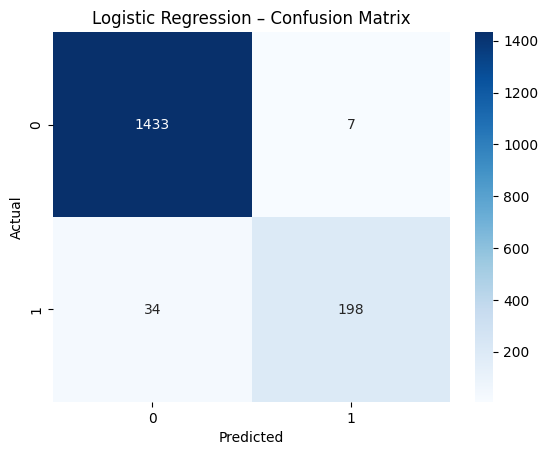

In [99]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression – Confusion Matrix")
plt.show()

The confusion matrix summarizes how well the Logistic Regression model classifies SMS messages as ham (0) or spam (1).
- **True positives (spam)**
198 messages were correctly classified as spam.

- **True negatives (ham)**
1433 messages were correctly classified as ham.

- **False negatives (spam → ham)**
34 messages were incorrectly classified as ham, while being spam. This is the most important error in spam detection. However, with 198 correctly identified spam messages, the recall is still strong.

- **False positives (ham → spam)**
7 messages were incorrectly classified as spam, while being ham.

In [100]:
false_positives = X_test[(y_test == 0) & (y_pred == 1)]
false_negatives = X_test[(y_test == 1) & (y_pred == 0)]

print("FALSE POSITIVES (ham misclassified as spam):\n")
for i, msg in false_positives.head(5).items():
    print(f"Index {i}:")
    print(msg)
    print()

print("\nFALSE NEGATIVES (spam misclassified as ham):\n")
for i, msg in false_negatives.head(5).items():
    print(f"Index {i}:")
    print(msg)
    print()

FALSE POSITIVES (ham misclassified as spam):

Index 1865:
Call to the number which is available in appointment And ask to connect the call to waheed fathima

Index 4771:
Hi Mobile no  ltgt  has added you in their contact list on wwwfullonsmscom It s a great place to send free sms to people For more visit fullonsmscom

Index 5085:
Sorry i missed your call Can you please call back

Index 1383:
Please reserve ticket on saturday eve from chennai to thirunelvali and again from tirunelvali to chennai on sunday evei already see in netno ticket availablei want to book ticket through tackle 

Index 1324:
Can you call me plz Your number shows out of coveragd area I have urgnt call in vasai amp have to reach before 4o clock so call me plz


FALSE NEGATIVES (spam misclassified as ham):

Index 5466:
httptms widelivecomindex wmlid820554ad0a1705572711firsttrueåÁC C RingtoneåÁ

Index 2769:
Burger King  Wanna play footy at a top stadium Get 2 Burger King before 1st Sept and go Large or Super with CocaC

**False positives** contain everyday, legitimate communication but include spam-like trigger words (e.g., call, number, mobile, ticket). These messages look normal but share vocabulary patterns commonly found in spam, which causes the classifier to overreact.

**False negatives** are subtle promotional spam messages that do not use strong spam keywords or contain unusual words, URLs, and symbols. Because they resemble regular notifications or advertisements, the model fails to detect them as spam.

In [101]:
probabilty = model.predict_proba(X_test_vectorized)

print(probabilty)

[[0.99394616 0.00605384]
 [0.98714623 0.01285377]
 [0.99463976 0.00536024]
 ...
 [0.99712088 0.00287912]
 [0.9951966  0.0048034 ]
 [0.98366617 0.01633383]]


**Left column (0):** probability that review is negative (class = -1) </br>
**Right column (0):** probability that review is positive (class = 1)

In [102]:
probs_pos = probabilty[:, 1]
sorted_idx = np.argsort(probs_pos)

top5_ham_idx = sorted_idx[:5]
top5_spam_idx = sorted_idx[-5:][::-1]

print("5 most likely spam messages:\n")
for i in reversed(top5_spam_idx):
    print(f"[prob = {probs_pos[i]:.4f}]")
    print(X_test.iloc[i], "\n")

print("\n5 least likely spam messages:\n")
for i in top5_ham_idx:
    print(f"[prob = {probs_pos[i]:.4f}]")
    print(X_test.iloc[i], "\n")

5 most likely spam messages:

[prob = 0.9999]
Do you want a New Nokia 3510i Colour Phone Delivered Tomorrow With 200 FREE minutes to any mobile  100 FREE text  FREE camcorder Reply or Call 8000930705 

[prob = 1.0000]
Gr8 new service  live sex video chat on your mob  see the sexiest dirtiest girls live on ur phone  4 details text horny to 89070 to cancel send STOP to 89070 

[prob = 1.0000]
FREE UNLIMITED HARDCORE PORN direct 2 your mobile Txt PORN to 69200  get FREE access for 24 hrs then chrgd50p per day txt Stop 2exit This msg is free 

[prob = 1.0000]
You have WON a guaranteed å£1000 cash or a å£2000 prize To claim yr prize call our customer service representative on 08714712379 between 10am7pm Cost 10p 

[prob = 1.0000]
We tried to call you re your reply to our sms for a video mobile 750 mins UNLIMITED TEXT  free camcorder Reply of call 08000930705 Now 


5 least likely spam messages:

[prob = 0.0000]
ltgt  is fast approaching So Wish u a very Happy New Year Happy Sankranti Happy 

Messages with the highest spam probability contain offers, sexually explicit content, promotional services, or statements about claiming a won prize.

The least likely spam messages consist of personal, conversational, and emotional content, often involving everyday life, relationships, storytelling, or well-wishing. These messages use natural, informal language without the typical promotional or attention-grabbing patterns associated with spam.

In [103]:
accuracy = model.score(X_test_vectorized, y_test)
print("Accuracy on test set:", accuracy)

Accuracy on test set: 0.9754784688995215


### Logistic regression solver comparison

In [104]:
for solver in ["liblinear", "saga"]:
    lr_tmp = LogisticRegression(solver=solver, max_iter=3000)
    lr_tmp.fit(X_train_vectorized, y_train)
    print(solver, lr_tmp.score(X_test_vectorized, y_test))


liblinear 0.9760765550239234
saga 0.9778708133971292


`liblinear` – Linear solver based on coordinate descent. Very good for small datasets and binary classification such as spam/ham.

`saga` – Uses stochastic gradient descent, works well on large and high-dimensional data like our dataset.

`lbfgs` – Quasi-Newton solver and the default in scikit-learn. Usually strong, but its performance depends on the dataset.

In our case, `saga` gave the best accuracy, followed by `liblinear`.
`lbfgs` performed the worst (≈0.975), suggesting that stochastic optimization works better for this dataset. The differences, however, are minimal, so every solver works well on our dataset (all above 0.975).

### Regularization strength (C parameter)

In [105]:
for C in [0.01, 0.1, 1, 10]:
    lr_tmp = LogisticRegression(C=C, max_iter=3000)
    lr_tmp.fit(X_train_vectorized, y_train)
    print("C =", C, "Accuracy:", lr_tmp.score(X_test_vectorized, y_test))

C = 0.01 Accuracy: 0.9204545454545454
C = 0.1 Accuracy: 0.9635167464114832
C = 1 Accuracy: 0.9754784688995215
C = 10 Accuracy: 0.9796650717703349


| **C value** | **Regularization strength** | **Accuracy** |
| ----------- | --------------------------- | ------------ |
| **0.01**    | Very strong                 | **0.9205**   |
| **0.1**     | Strong                      | **0.9635**   |
| **1**       | Medium                      | **0.9755**   |
| **10**      | Weak                        | **0.9797**   |


Weak regularization performs best in this case. The representation of our dataset is high-dimensional and nearly linearly separable, so Logistic Regression benefits from a more flexible model with higher C values.

## Decision tree

A Decision Tree maps out decisions and their outcomes. It starts with a root node and branches out into decisions. It’s used in machine learning for tasks like classification and prediction.

The Decision Tree model identifies the words with the highest importance during the classification process. These are the terms that create the strongest information gain when splitting the dataset. 

In [106]:
from sklearn.tree import DecisionTreeClassifier

In [107]:
dt = DecisionTreeClassifier(random_state=43)
dt.fit(X_train_vectorized, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,43
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [108]:
dt_pred = dt.predict(X_test_vectorized)

print("Decision Tree accuracy:", dt.score(X_test_vectorized, y_test))

Decision Tree accuracy: 0.958732057416268


The Decision Tree achieves high prediction accuracy, although its performance is slightly lower than that of Logistic Regression ($ \approx 0.975$)

In [109]:
importances = dt.feature_importances_
indices = np.argsort(importances)[-15:][::-1]

print("Top 15 words used by the Decision Tree:")
for idx in indices:
    print(words[idx], importances[idx])

Top 15 words used by the Decision Tree:
call 0.21079812377345844
txt 0.1662334161837177
me 0.06074757823829363
ill 0.04416753141937155
free 0.042495487082698916
my 0.029813028444910607
win 0.02513488241967199
500 0.022700058616350955
claim 0.02076742198907125
tones 0.018798325414902416
stop 0.018713510911175353
im 0.018693784367139404
admirer 0.014763573128749157
unsubscribe 0.012704676850008067
mobile 0.011951191767826089


The Decision Tree mainly focuses on communication- and promotion-related words ("call", "txt", "free", "win", "claim") when predicting spam. Meanwhile, common conversational words ("me", "ill", "im") help it identify ham messages.

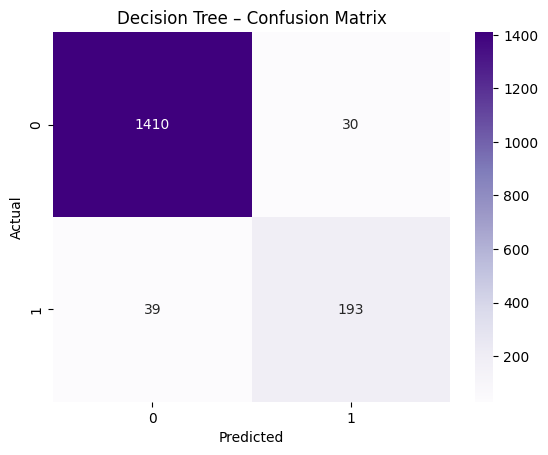

In [110]:
dt_cm = confusion_matrix(y_test, dt_pred)

sns.heatmap(dt_cm, annot=True, cmap="Purples", fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree – Confusion Matrix")
plt.show()

### Confusion matrix comparison: decision tree vs logistic regression

| Metric                       | Decision Tree | Logistic Regression |
| ---------------------------- | ------------- | ------------------- |
| True Positives (spam)        | 193           | 198                 |
| True Negatives (ham)         | 1410          | 1433                |
| False Positives (ham → spam) | 30            | 7                   |
| False Negatives (spam → ham) | 39            | 34                  |


In [111]:
dt_deep = DecisionTreeClassifier(max_depth=None, random_state=43)
dt_shallow = DecisionTreeClassifier(max_depth=5, random_state=43)

dt_deep.fit(X_train_vectorized, y_train)
dt_shallow.fit(X_train_vectorized, y_train)

print("Deep tree accuracy:", dt_deep.score(X_test_vectorized, y_test))
print("Shallow tree accuracy:", dt_shallow.score(X_test_vectorized, y_test))


Deep tree accuracy: 0.958732057416268
Shallow tree accuracy: 0.9300239234449761


`max_depth` controls the maximum depth of the decision tree
- Deep tree (`max_depth=None`) - it can grow untill all splits are exhausted. It becomes very detailed, learns many specific patterns, and can fit even rare cases. It has higher accuracy that comes with a risk of overfitting.
- Shallow tree (`max_depth=5`) - the tree is limited to only 5 levels.
It becomes simpler, focuses on the most important features, and produces more generalized decision rules, but at the cost of lower accuracy.

Increasing the tree depth allows the model to learn more detailed patterns in the training data, which improves accuracy but also increases the risk of overfitting. A shallow tree generalizes better but sacrifices some prediction power because it cannot capture complex patterns in the data.

## AdaBoost (Adaptive Boosting)

AdaBoost (Adaptive Boosting) is an ensemble method that builds multiple weak classifiers (typically decision stumps with depth 1) and iteratively focuses on samples that were previously misclassified. Each new classifier puts more emphasis on difficult examples, and the final model is a weighted combination of all weak learners.

In [85]:
from sklearn.ensemble import AdaBoostClassifier


base = DecisionTreeClassifier(max_depth=1)

ada = AdaBoostClassifier(
    estimator=base, 
    n_estimators=50,
    random_state=43
)

ada.fit(X_train_vectorized, y_train)

print("AdaBoost accuracy:", ada.score(X_test_vectorized, y_test))

AdaBoost accuracy: 0.9318181818181818


AdaBoost performs worse because decision stumps cannot model complex text patterns in a high-dimensional space. The algorithm boosts noisy examples and rare words, which reduces generalization. Logistic Regression, which learns a global linear decision boundary across all word features, is much better suited to this kind of data.